In [1]:
import numpy as np
import hopsy
import scipy.special
import matplotlib.pyplot as plt
import mph
import os
import pandas as pd
import concurrent.futures
import time

# Step one: uniformly sample the parameters for the physical parameter approximation functions while maintaining the physical constrains
Currently 10,000 physically allowed parameter set are sampled

Setting up Markov Chain...
Sampling... (This may take a moment due to high thinning)
Sampling complete! Generated 100000 valid parameter sets.
Acceptance Rate: 100.0%
Sample shape: (100000, 20) (Should be [100000, 20])


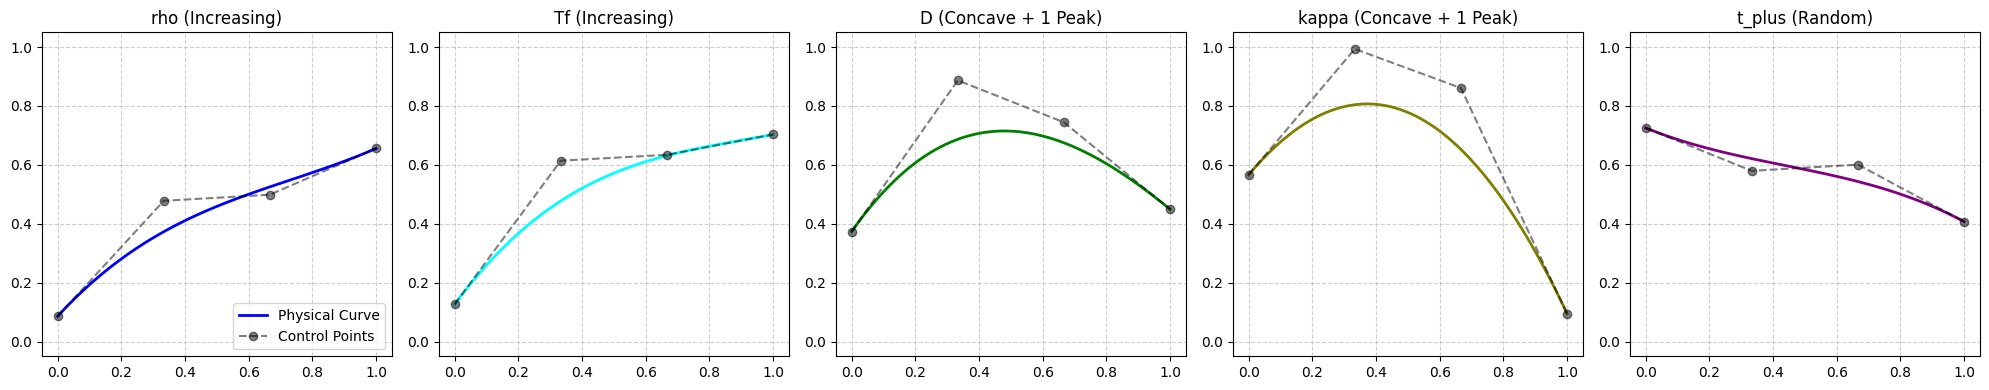

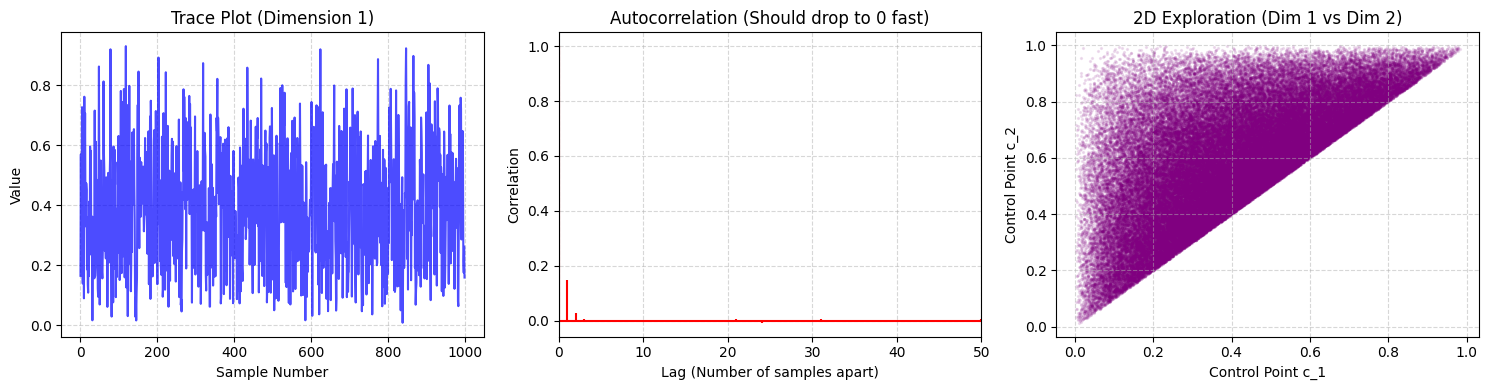

In [2]:

# ==========================================
# 1. Define the Core Constraint Matrices
# ==========================================

# Rule 1: Bounding Box (0 <= x <= 1)
A_0_1 = np.array([
    [ 1,  0,  0,  0],  # x_i <= 1
    [ 0,  1,  0,  0],  
    [ 0,  0,  1,  0],  
    [ 0,  0,  0,  1],  
    [-1,  0,  0,  0],  # -x_i <= 0  (meaning x_i >= 0)
    [ 0, -1,  0,  0],  
    [ 0,  0, -1,  0],  
    [ 0,  0,  0, -1]   
])
b_0_1 = np.array([1, 1, 1, 1, 0, 0, 0, 0])

# Rule 2: First Derivative > 0 (Monotonically Increasing)
A_d1 = np.array([
    [ 1, -1,  0,  0],  # x_0 - x_1 <= 0
    [ 0,  1, -1,  0],  # x_1 - x_2 <= 0
    [ 0,  0,  1, -1]   # x_2 - x_3 <= 0
])
b_d1 = np.array([0, 0, 0])

# Rule 3: Second Derivative < 0 (Concave Down / Dome shape)
A_d2 = np.array([
    [ 1, -2,  1,  0],  # x_0 - 2x_1 + x_2 <= 0
    [ 0,  1, -2,  1]   # x_1 - 2x_2 + x_3 <= 0
])
b_d2 = np.array([0, 0])

# Rule 4: Exactly one maximum (Forces curve to start UP and end DOWN)
A_peak = np.array([
    [ 1, -1,  0,  0],  # x_0 - x_1 <= 0 (Step 1 is positive)
    [ 0,  0, -1,  1]   # x_3 - x_2 <= 0 (Step 3 is negative)
])
b_peak = np.array([0, 0])


# ==========================================
# 2. Allocate Global A and b Matrices
# ==========================================
# 5 Parameters: rho (0), Tf (1), D (2), kappa (3), t_plus (4)
# 4 coefficients per parameter = 20 columns total

total_rows = (5 * len(A_0_1)) + (2 * len(A_d1)) + (2 * len(A_d2)) + (2 * len(A_peak))

A = np.zeros((total_rows, 20))
b = np.zeros(total_rows)

row_idx = 0

# ==========================================
# 3. Apply Constraints to Specific Parameters
# ==========================================

# Apply Bounding Box [0, 1] to ALL 5 parameters
for i in range(5):
    rows = len(A_0_1)
    A[row_idx : row_idx+rows, i*4 : (i+1)*4] = A_0_1
    b[row_idx : row_idx+rows] = b_0_1
    row_idx += rows

# Apply Monotonically Increasing constraint to 'rho' (0) and 'Tf' (1)
for i in [0, 1]:
    rows = len(A_d1)
    A[row_idx : row_idx+rows, i*4 : (i+1)*4] = A_d1
    b[row_idx : row_idx+rows] = b_d1
    row_idx += rows

# Apply Concave Down AND Exact Peak constraint to 'D' (2) and 'kappa' (3)
for i in [2, 3]:
    # Concavity
    rows_d2 = len(A_d2)
    A[row_idx : row_idx+rows_d2, i*4 : (i+1)*4] = A_d2
    b[row_idx : row_idx+rows_d2] = b_d2
    row_idx += rows_d2
    
    # Peak
    rows_peak = len(A_peak)
    A[row_idx : row_idx+rows_peak, i*4 : (i+1)*4] = A_peak
    b[row_idx : row_idx+rows_peak] = b_peak
    row_idx += rows_peak

# Note: 't_plus' (index 4) remains fully unconstrained inside the [0, 1] box.


# ==========================================
# 4. Run Hopsy MCMC Sampler
# ==========================================
print("Setting up Markov Chain...")
problem = hopsy.Problem(A, b)
chain = hopsy.MarkovChain(problem, proposal=hopsy.UniformHitAndRunProposal)
rng = hopsy.RandomNumberGenerator(seed=42)

print("Sampling... (This may take a moment due to high thinning)")
# High thinning (500) ensures consecutive samples are highly independent
# 100,000 samples is usually plenty for 20D when hit-and-run is used
acc_rates, states = hopsy.sample(chain, rng, n_samples=100000, thinning=500, n_threads=8)

samples = states[0]
print(f"Sampling complete! Generated {len(samples)} valid parameter sets.")
print(f"Acceptance Rate: {acc_rates[0] * 100}%")
print(f"Sample shape: {samples.shape} (Should be [100000, 20])")

# ==========================================
# 5. Visualization (All 5 Parameters)
# ==========================================
def evaluate_bezier(control_points, num_points=100):
    t = np.linspace(0, 1, num_points)
    n = len(control_points) - 1
    curve = np.zeros(num_points)
    for i, p in enumerate(control_points):
        bernstein = scipy.special.comb(n, i) * (t**i) * ((1 - t)**(n - i))
        curve += p * bernstein
    return t, curve

# Pick a random sample from the chain
random_idx = np.random.randint(0, len(samples))
my_sample = samples[random_idx]

# Extract all 5 sets of coefficients
rho_coeffs   = my_sample[0:4]   
Tf_coeffs    = my_sample[4:8]   
D_coeffs     = my_sample[8:12]  
kappa_coeffs = my_sample[12:16] 
tplus_coeffs = my_sample[16:20] 

# Plotting a 1x5 grid
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

parameters = [
    ("rho (Increasing)", rho_coeffs, 'blue'),
    ("Tf (Increasing)", Tf_coeffs, 'cyan'),
    ("D (Concave + 1 Peak)", D_coeffs, 'green'),
    ("kappa (Concave + 1 Peak)", kappa_coeffs, 'olive'),
    ("t_plus (Random)", tplus_coeffs, 'purple')
]

for ax, (title, coeffs, color) in zip(axs, parameters):
    x_vals, curve = evaluate_bezier(coeffs)
    ax.plot(x_vals, curve, color=color, linewidth=2, label="Physical Curve")
    ax.plot(np.linspace(0, 1, 4), coeffs, 'ko--', alpha=0.5, label="Control Points")
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Only add the legend to the first plot to save space
    if ax == axs[0]:
        ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
plt.show()

# Let's look at just ONE specific dimension to judge the chain's health.
# For example, index 1 is the second control point of 'rho'.
dim_to_plot = 1 
chain_data = samples[:, dim_to_plot]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# ---------------------------------------------------------
# Plot 1: The Trace Plot (History)
# ---------------------------------------------------------
# We plot the first 1,000 samples to avoid crowding the screen
ax1.plot(chain_data[:1000], alpha=0.7, color='blue')
ax1.set_title(f"Trace Plot (Dimension {dim_to_plot})")
ax1.set_xlabel("Sample Number")
ax1.set_ylabel("Value")
ax1.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Plot 2: Autocorrelation (ACF)
# ---------------------------------------------------------
# Matplotlib has a built-in autocorrelation plotting function!
# We subtract the mean first to center it around 0.
mean_val = np.mean(chain_data)
ax2.acorr(chain_data - mean_val, maxlags=50, color='red')
ax2.set_title("Autocorrelation (Should drop to 0 fast)")
ax2.set_xlabel("Lag (Number of samples apart)")
ax2.set_ylabel("Correlation")
ax2.set_xlim(0, 50) # Only look at forward lags
ax2.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Plot 3: 2D Scatter (Mixing / Exploration)
# ---------------------------------------------------------
# Let's plot dim 1 vs dim 2 (the middle two control points of rho)
# to see how well it explored the available 2D space.
ax3.scatter(samples[:, 1], samples[:, 2], alpha=0.1, s=2, color='purple')
ax3.set_title("2D Exploration (Dim 1 vs Dim 2)")
ax3.set_xlabel("Control Point c_1")
ax3.set_ylabel("Control Point c_2")
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Write the Helper file for parallel synthetic data generation

In [ ]:
%%writefile comsol_tasks.py
import mph
import pandas as pd
import os
model_path = 'Mass_Production.mph'


def worker(comsol_params, worker_number):
    """Performs jobs and delivers the results."""
    log_file = f"log\\worker_{worker_number}_log.txt"
    def log(msg):
        with open(log_file, "a") as f:
            f.write(msg + "\n")
            
    log(f"--- Starting Worker {worker_number} ---")
    log("recceived parameters:" + ", ".join(comsol_params))
    try:
        client = mph.start(cores=1)
        model = client.load(model_path)
        log("Model loaded successfully.")
        std1 = model/'studies'/'Study 1'/'Parametric Sweep'
        std1.java.set("plistarr", comsol_params)
        log("Parameters set in COMSOL model.")
        log("Running COMSOL simulation...")
        model.solve('Study 1')
        log("COMSOL simulation completed.")
        log("Exporting results...")
        export1 = model/'exports'/'Data 1'
        export2 = model/'exports'/'Data 2'
        export1_filename = f"C:\\Users\\Junbo\\OneDrive\\Desktop\\Chem 242\\Project\\comsol_results\\batch_{worker_number}_conc.csv"
        export1.java.set("filename", export1_filename)
        export2_filename = f"C:\\Users\\Junbo\\OneDrive\\Desktop\\Chem 242\\Project\\comsol_results\\batch_{worker_number}_dV.csv"
        export2.java.set("filename", export2_filename)
        export1.java.run()
        export2.java.run()
    except Exception as e:
        log(f"Worker {worker_number} encountered an error: {e}")
        
    finally:
        # Always disconnect, even if an error occurs, to free up RAM
        model.clear()
        client.disconnect()


# COMSOL synthetic data generation
Currently 2000 sample is generated, more data could be generated if needed. 

In [ ]:
# ---------------------------------------------------------
# The following section is not excutable without appropriate COMSOL file
# ---------------------------------------------------------


# Import the worker function from the file Jupyter just created for us
from comsol_tasks import worker

def format_df_for_comsol(df):
    """
    Converts a DataFrame of coefficients into a format ready for COMSOL's Parametric Sweep.
    
    Args:
        df (pd.DataFrame): DataFrame where columns are parameter names and rows are samples.
        
    Returns:
        dict: A dictionary where keys are parameter names (strings) and 
              values are space-separated strings of the column data.
    """
    comsol_params = []
    
    for col in df.columns:
        # 1. Convert the entire column to strings
        # 2. Extract to a Python list
        # 3. Join with spaces
        param_string = " ".join(df[col].values.astype(str).tolist())
        comsol_params.append(param_string)
        
    return comsol_params

def run_parallel_sweep():
    # Load your dataframe
    coefficient_df = pd.read_csv('hopsy_samples.csv')
    
    workers = 10
    queue_length = 200
    
    print(f"Starting {workers} parallel COMSOL instances...")
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=workers) as executor:
        futures = []
        
        for worker_number in range(workers):
            # Grab the chunk of data for this worker
            chunk = coefficient_df.iloc[worker_number * queue_length : (worker_number + 1) * queue_length, :]
            chunk = format_df_for_comsol(chunk)
            # Submit the job to the background executor
            future = executor.submit(worker, chunk, worker_number)
            futures.append(future)
            
            print(f"Dispatched Worker {worker_number}...")
            # Stagger the boot sequence by 5 seconds to prevent COMSOL licensing crashes
            time.sleep(5) 
            
        print("All workers dispatched. Waiting for them to finish...")
        
        # This forces Jupyter to pause and wait until all workers are done
        concurrent.futures.wait(futures)
        
    print("All parallel sweeps completed! Check your folder for the CSVs and Log files.")

# Execute it
run_parallel_sweep()

# Plot the normalized data for 20 random sample

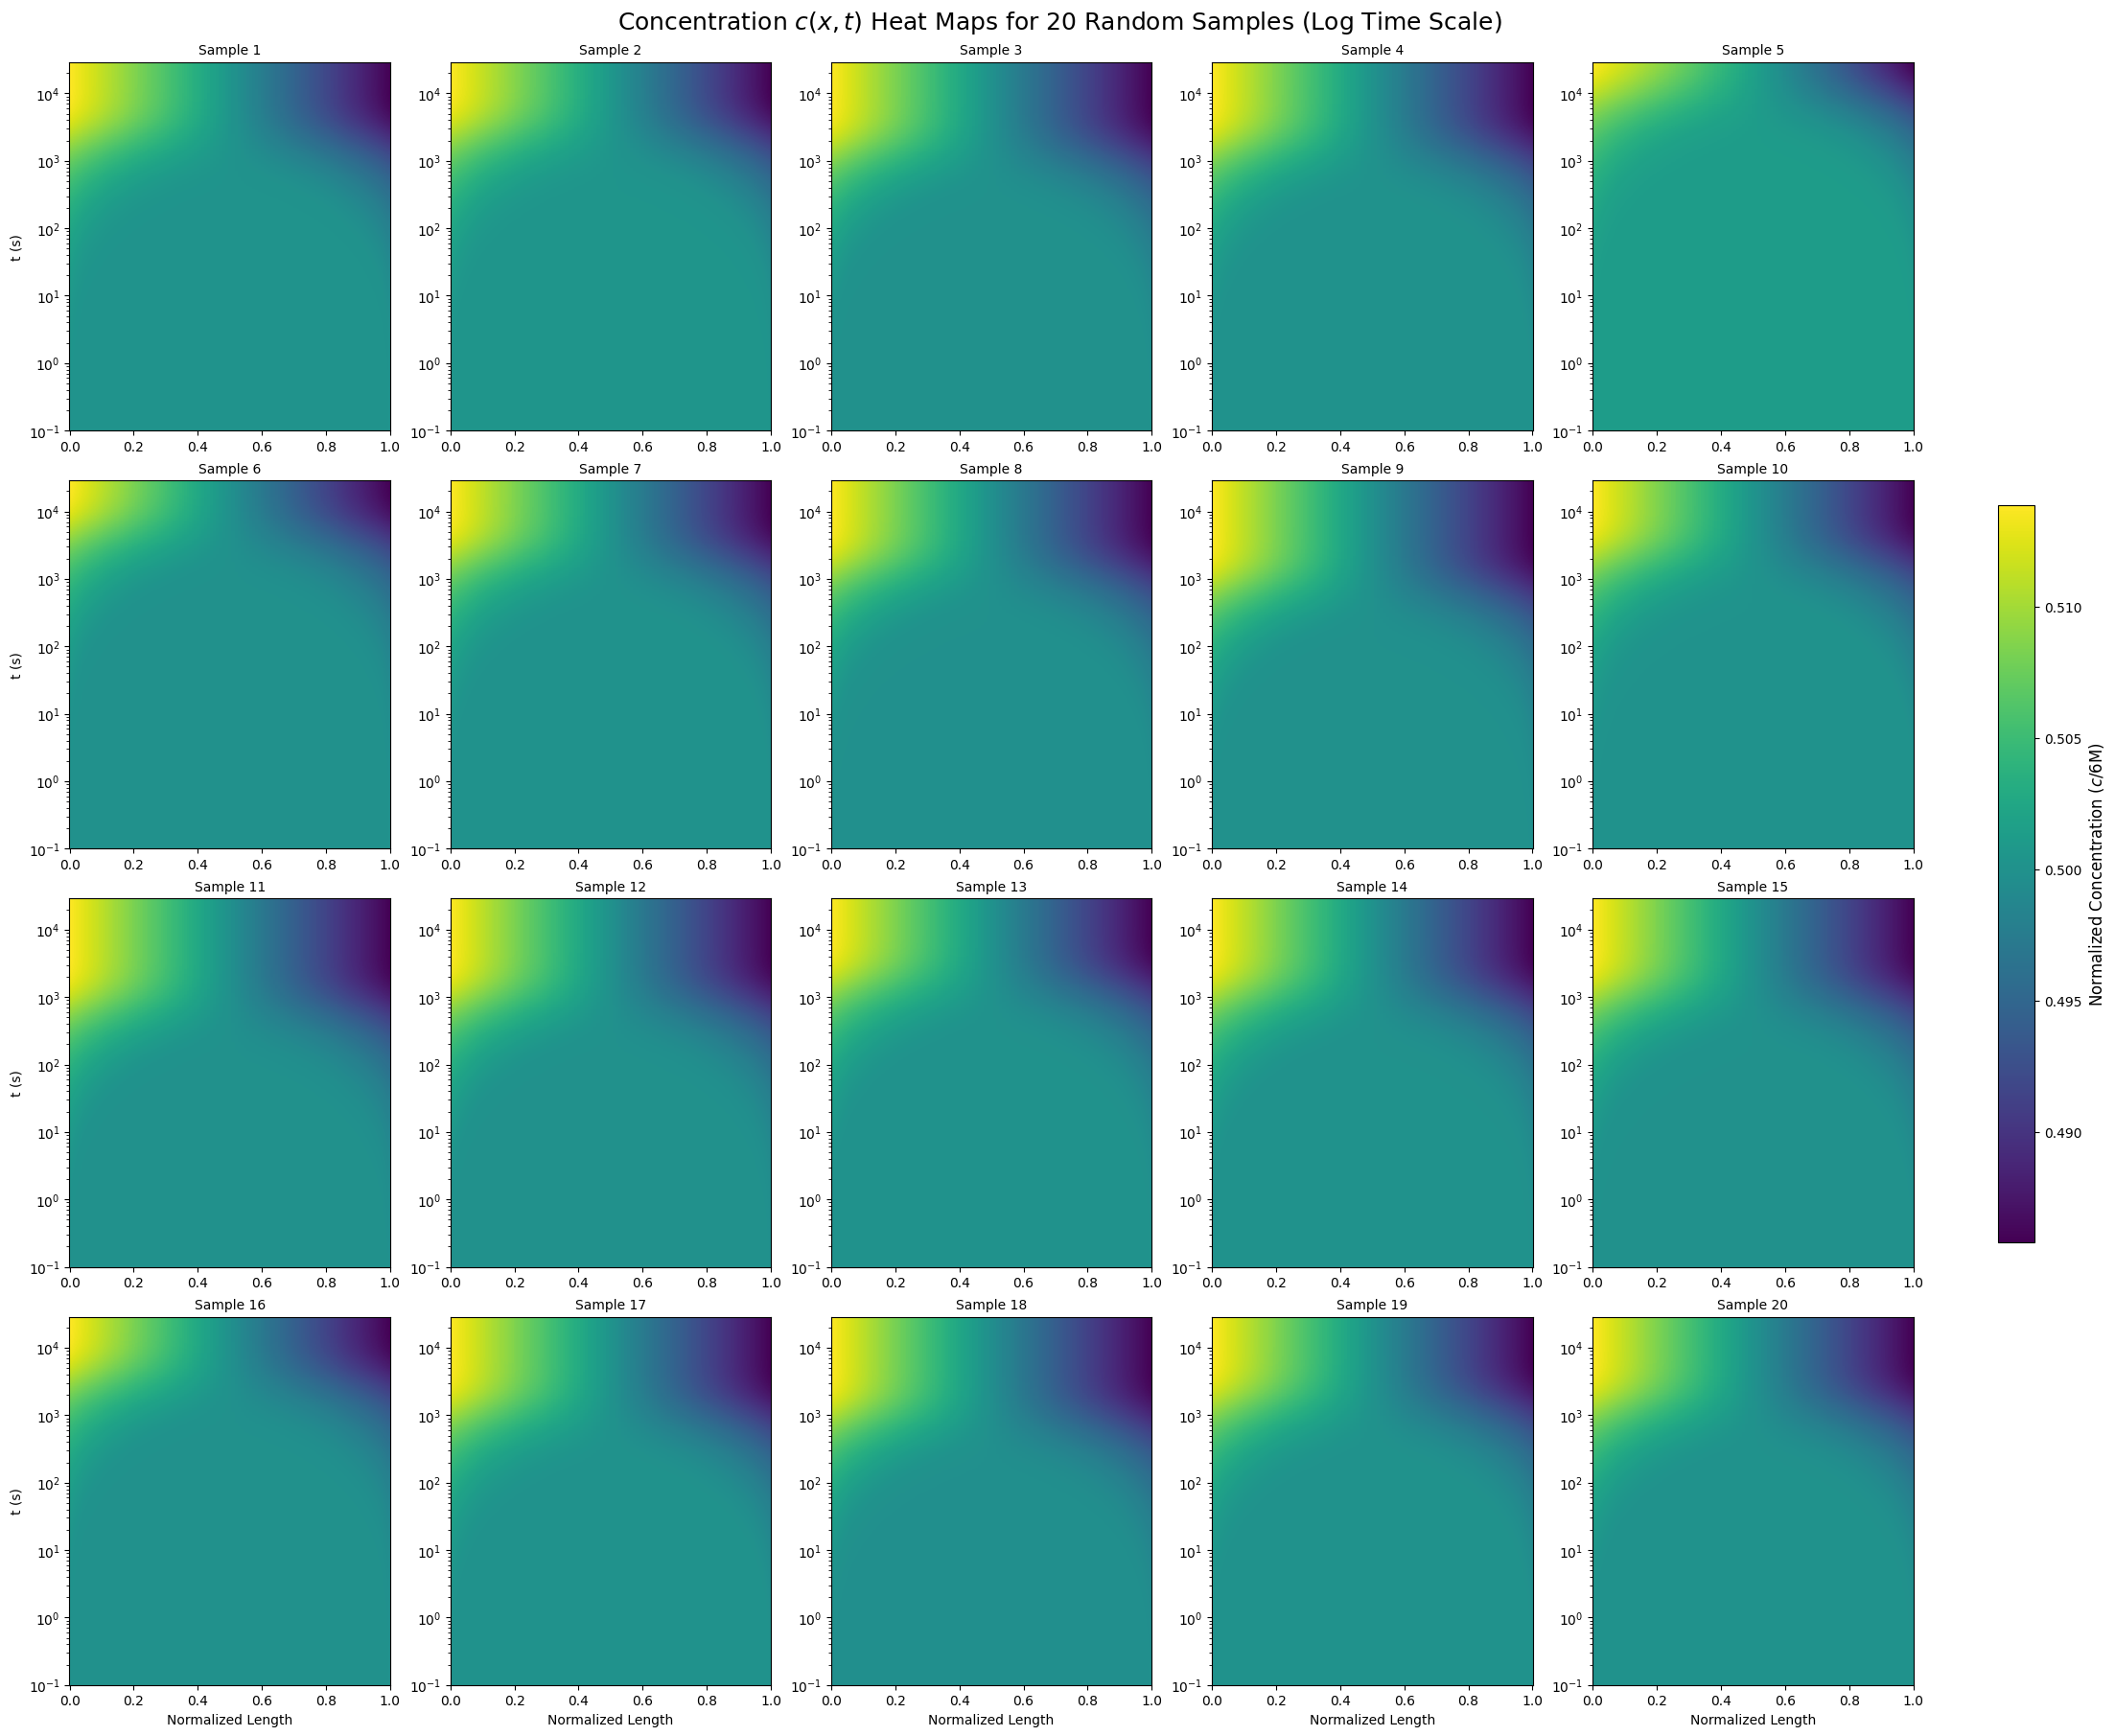

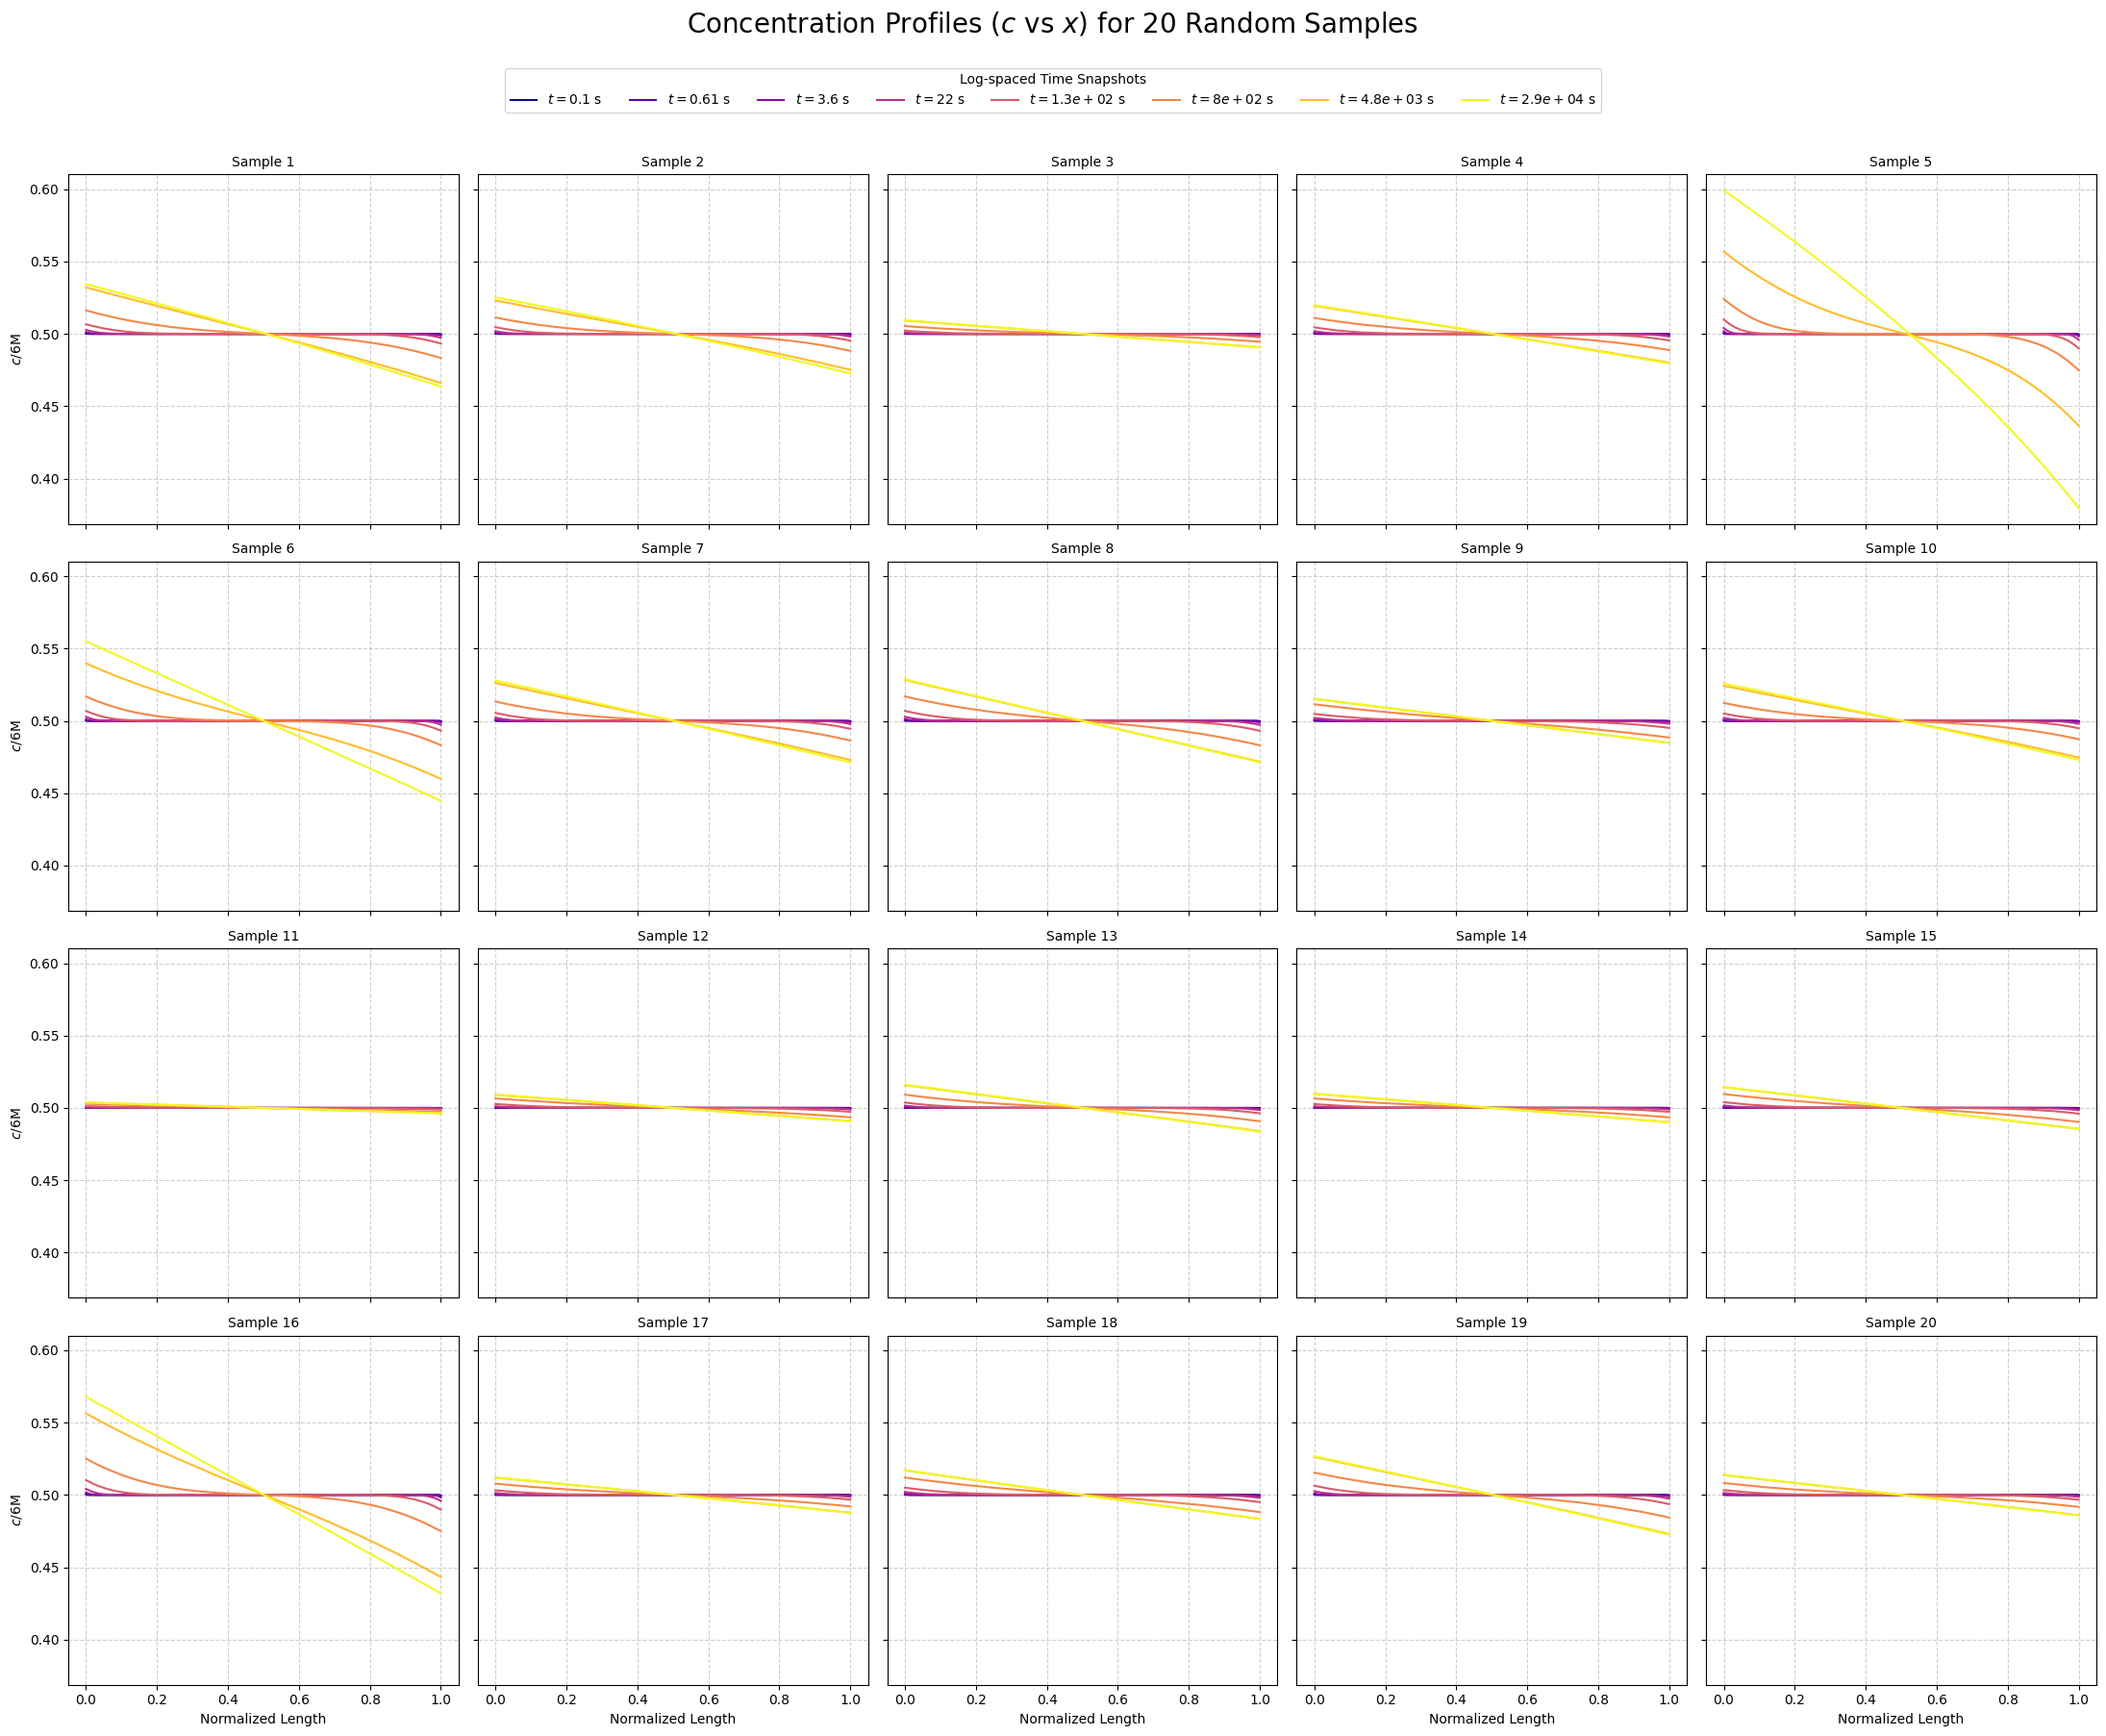

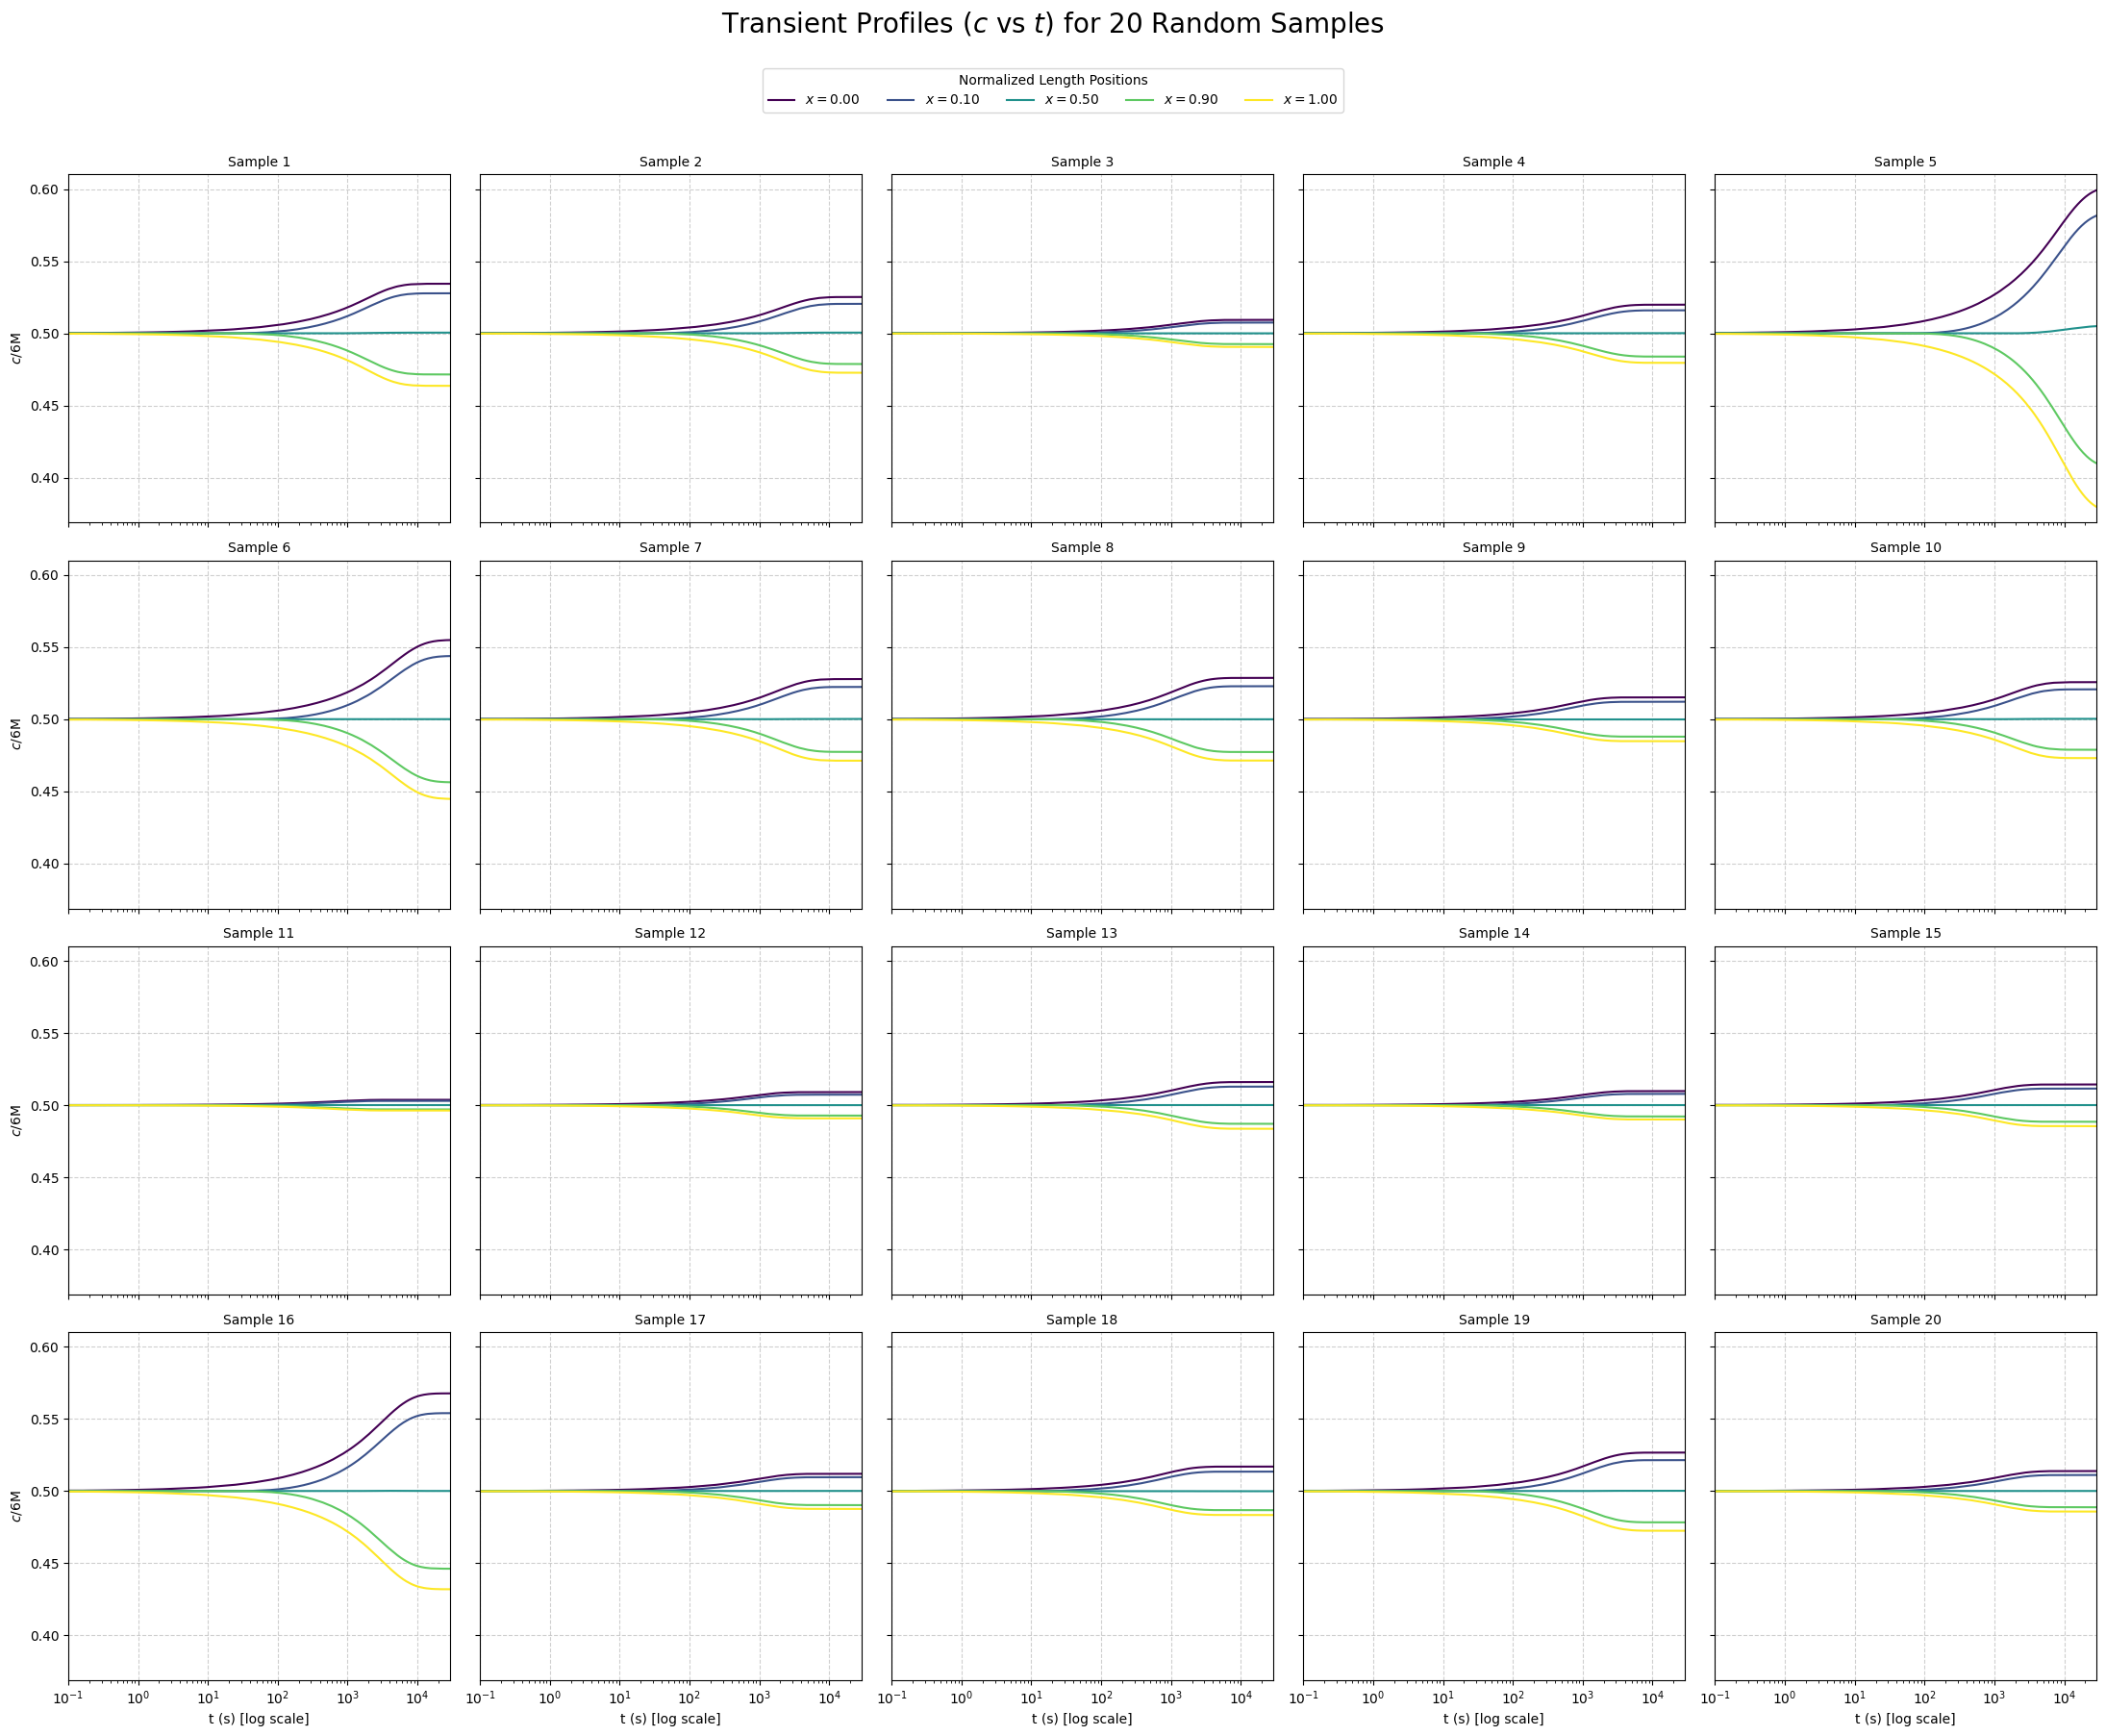

In [3]:
# ==========================================
# 1. Load Data
# ==========================================
sample_dir = 'comsol_results/batch_2_conc.csv'
# If you run into issues, verify the separator and comment symbol
data = pd.read_csv(sample_dir, sep=',', comment='%')

# Identify the unique grid dimensions
x_coords = data['X'].unique() / 580.0
t_coords = data['t'].unique()
num_x = len(x_coords)
num_t = len(t_coords)

# ==========================================
# 2. Select the SAME 20 Random Samples
# ==========================================
# Filter for concentration columns only
c_cols = np.array([col for col in data.columns if col.startswith('c (mol/m^3)')])

# Set random seed for reproducibility (optional but recommended)
rng = np.random.default_rng(seed=42)

# Choose 20 random sample columns without replacement
samples_to_plot = rng.choice(c_cols, size=20, replace=False)

# Define coordinate grids for pcolormesh
X_grid, T_grid = np.meshgrid(x_coords, t_coords)

# Find first non-zero time step to safely set lower bounds for log-scale axes
t_min = t_coords[t_coords > 0].min()

# ==========================================
# 3. Plot 1: Heat maps (log-time scale on y-axis)
# ==========================================
fig1, axes1 = plt.subplots(4, 5, figsize=(22, 18), constrained_layout=True)
axes1 = axes1.flatten()

for i, col_name in enumerate(samples_to_plot):
    ax = axes1[i]
    
    # Reshape the 1D column into 2D (time x space)
    # The CSV structure (X slow, t fast) requires reshape(num_x, num_t).T
    grid_data = data[col_name].values.reshape((num_x, num_t)).T
    
    # Normalize by 6000 (6M)
    grid_data_norm = grid_data / 6000.0
    
    # Use pcolormesh to allow for non-linear (log) axis scaling
    im = ax.pcolormesh(X_grid, T_grid, grid_data_norm, cmap='viridis', shading='auto')
    
    # Set y-axis (time) to log scale
    ax.set_yscale('log')
    ax.set_ylim(t_min, t_coords.max())
    
    ax.set_title(f"Sample {i+1}", fontsize=10)
    if i >= 15: 
        ax.set_xlabel("Normalized Length")
    if i % 5 == 0: 
        ax.set_ylabel("t (s)")

# Add a shared colorbar
cbar1 = fig1.colorbar(im, ax=axes1, orientation='vertical', fraction=0.02, pad=0.04)
cbar1.set_label(r'Normalized Concentration ($c/6\text{M}$)', fontsize=12)

fig1.suptitle("Concentration $c(x, t)$ Heat Maps for 20 Random Samples (Log Time Scale)", fontsize=18)
plt.savefig('heatmap_log_t.png', dpi=300)

# ==========================================
# 4. Plot 2: Line plots (c vs x) with Log-spaced Time Snapshots
# ==========================================
positive_times = t_coords[t_coords > 0]
log_t = np.log10(positive_times)

# Select 8 snapshots evenly spaced in log10 space
log_t_snapshots = np.linspace(log_t.min(), log_t.max(), 8)
selected_times = [positive_times[np.argmin(np.abs(log_t - val))] for val in log_t_snapshots]
selected_times = np.unique(selected_times) # Ensure no duplicate snapshot pulls

fig2, axes2 = plt.subplots(4, 5, figsize=(22, 18), sharex=True, sharey=True)
axes2 = axes2.flatten()

colors = plt.cm.plasma(np.linspace(0, 1, len(selected_times)))

for i, col_name in enumerate(samples_to_plot):
    ax = axes2[i]
    for idx, t_val in enumerate(selected_times):
        # Filter data for this specific time snapshot
        subset = data[data['t'] == t_val].sort_values('X')
        
        # Use double braces {{ }} around 's' unit for LaTeX formatting
        label_text = rf"$t = {t_val:.2g} \text{{ s}}$" if i == 0 else ""
        
        ax.plot(subset['X'] / 580.0, subset[col_name] / 6000.0, 
                color=colors[idx], 
                label=label_text)

    ax.set_title(f"Sample {i+1}", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Labels for outer plots
    if i >= 15: 
        ax.set_xlabel("Normalized Length")
    if i % 5 == 0: 
        ax.set_ylabel(r"$c / 6\text{M}$")

# Global legend and layout
handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), 
           ncol=len(selected_times), title="Log-spaced Time Snapshots")

fig2.suptitle("Concentration Profiles ($c$ vs $x$) for 20 Random Samples", fontsize=20, y=1.0)
fig2.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('lineplot_cvsx_log_t_snapshots.png', dpi=300)

# ==========================================
# 5. Plot 3: Line plots (c vs t) with log-time scale (X-axis)
# ==========================================
# Select 5 representative X positions linearly
x_indices = np.linspace(0, len(x_coords)-1, 5, dtype=int)
selected_x = x_coords[x_indices]

fig3, axes3 = plt.subplots(4, 5, figsize=(22, 18), sharex=True, sharey=True)
axes3 = axes3.flatten()

colors_x = plt.cm.viridis(np.linspace(0, 1, len(selected_x)))

for i, col_name in enumerate(samples_to_plot):
    ax = axes3[i]
    
    # Extract temporal data cleanly from our reshaped grid logic
    grid_data = data[col_name].values.reshape((num_x, num_t))
    grid_data_norm = grid_data / 6000.0
    
    for idx, x_idx in enumerate(x_indices):
        label_text = rf"$x = {selected_x[idx]:.2f}$" if i == 0 else ""
        ax.plot(t_coords, grid_data_norm[x_idx, :], 
                color=colors_x[idx], 
                label=label_text)

    # Set x-axis (time) to log scale
    ax.set_xscale('log')
    ax.set_xlim(t_min, t_coords.max())
    
    ax.set_title(f"Sample {i+1}", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Labels for outer plots
    if i >= 15: 
        ax.set_xlabel("t (s) [log scale]")
    if i % 5 == 0: 
        ax.set_ylabel(r"$c / 6\text{M}$")

# Global legend and layout
handles, labels = axes3[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), 
           ncol=len(selected_x), title="Normalized Length Positions")

fig3.suptitle("Transient Profiles ($c$ vs $t$) for 20 Random Samples", fontsize=20, y=1.0)
fig3.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('lineplot_cvst_log_t.png', dpi=300)

# Finally, display the plots visually
plt.show()